# The blip-function method of Andersen, Weeks and Chandler (AWC)
This note is about the solid-liquid coexistence line of the WCA model where particles interact via the Lennard-Jones pair potential truncated and shifted at the minimum:
$$
   v(r) = 4\varepsilon [(\sigma/r)^{12}-(\sigma/r)^{6}]+\varepsilon \text{ for }r<2^{1/6}\sigma
$$
and zero otherwise. We have computed the coexistence line to high precision, and here we wish to compare analytical predictions for the shape of the coexistence line of the WCA potential. At low temperature the WCA potential can be approximate as (see Appendix below)
$$
   v(x) = k_2x^2/2
$$
where $x=r_c-r$ and $k_2=36\sqrt[3]{4}\varepsilon/\sigma^2$.

Let $T=1/\beta$ be the temperature $\rho=N/V$ be the number density.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
import sympy
#%matplotlib notebook
%matplotlib inline

/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# The analytical Percus-Yevic theory for Hard-Spheres

*Here I will not define the radial functions $g$, $c$, $f$, and $y$, but follow the notation of Hansen-McDonald*

To evaluate the AWC theory we need an expression for the hard-sphere cavity function $y(r)$. We have that
$$
    y(r) = -c(r) \textrm{ for }r<d
$$
and
$$
    y(r)=g(r) \textrm{ for } r>d
$$
Let
$$
    x=r/d
$$
be the reduced distance and 
$$
    \eta=\pi\rho d^3/6
$$
be the packing fraction. The approximate analytical solution for the "zeroth shell" (first derived by Wertheim) is
$$
  c(x)=-\lambda_1 - 6\eta\lambda_2x-\frac{1}{2}\eta\lambda_1x^3
$$
where 
$$
  \lambda_1 = (1+2\eta)^2/(1-\eta)^4
$$
and
$$
  \lambda_2 = -(2+\eta)^2/4(1-\eta)^4
$$

As an aside, we note that the pressure $p$ of the Hard-Sphere system is given by
$\beta P/\rho = 1+\frac{2\pi\rho}{3}\lim_{r\rightarrow d^+} r^3y(r) = 1+\frac{2\pi\rho d^3}{3}g(d)$
givin the PY equation of state (this is refered to as "the virial equation of state" $P^\textrm{v}$ in Hansen-McDonald")
$$
   \beta P/\rho = \frac{1+2\eta+3\eta^2}{(1-\eta)^2}
$$
Below we evaluate $y(r)$ at the liquid coexistence density $\rho=0.9375$.

In [3]:
# Evaluation of coexistence packing fraction.
d = 1
rho = 0.9375  # Coexistence density from litterature
eta = np.pi*rho*d**3/6
print('Packing fraction at coexistence:', eta)

Packing fraction at coexistence: 0.4908738521234051


lambda_1 58.45142703289916
lambda_2 -23.08563723870309


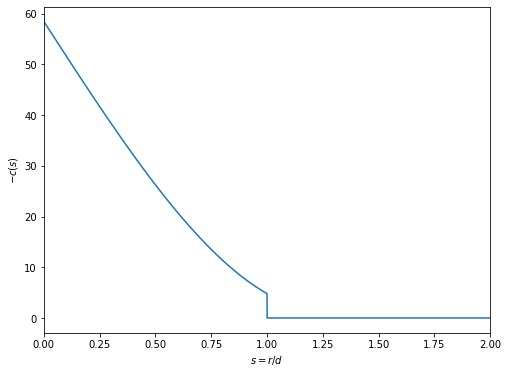

In [4]:
# Evaluation of the cavity function within the PY approximation
r = np.linspace(0, 6.0, 2**16)
lambda_1 = (1+2*eta)**2/(1-eta)**4
print('lambda_1', lambda_1)
lambda_2 = -(2+eta)**2/(4*(1-eta)**4)
print('lambda_2', lambda_2)
x = r/d
c = (-lambda_1-6*eta*lambda_2*x-0.5*eta*lambda_1*x**3)*np.heaviside(1-x, 0.5)

plt.figure(figsize=(8, 6))
plt.plot(r, -c)
plt.xlim(0, 2)
plt.xlabel('$s=r/d$')
plt.ylabel('$-c(s)$')
plt.show()

We can also write the direct correlation function as
$$
  c(r) = -c_0 + c_1x - c_3 x^3
$$
below are the $c$-coefficiets.

In [4]:
c_0 = lambda_1
print(f'c_0 = {c_0:0.4f}')

c_0 = 58.4514


In [5]:
c_1 = -6*eta*lambda_2
print(f'c_1 = {c_1:0.4f}')

c_1 = 67.9928


In [6]:
c_3 = 0.5*eta*lambda_1
print(f'c_3 = {c_3:0.4f}')

c_3 = 14.3461


Below we compare the pressure of the theory and compare it to that of the numerical calculations (at the coexistence density).

The "virial" pressure ($P^v$ in [Hansen & McDonald]) is

In [7]:
P = rho*(1+2*eta+4*eta**2)/(1-eta)**2
print("PY viral prediction: ", P)
print("... from numerical calculations", 11.5727)
print(f"Relative error: {(1-P/11.5727)*100:.1f} %")

PY viral prediction:  10.6534615481584
... from numerical calculations 11.5727
Relative error: 7.9 %


The coexistence pressure of the PY theory is underestimated by only 7.9%. Below we evaluate the "compressability pressure" ($P^{c}$ in [Hansen & McDonald])

In [8]:
P = rho*(1+eta+eta**2)/(1-eta)**3
print("PY compressibility prediction: ", P)
print("... from numerical calculations", 11.5727)
print(f"Relative error: {(1-P/11.5727)*100:.1f} %")

PY compressibility prediction:  12.302704043021544
... from numerical calculations 11.5727
Relative error: -6.3 %


The Carnahan-Starling formular is reproduced from the weighted average $\frac{2}{3}P^c+\frac{1}{3}P^v$

In [9]:
# Empirical Carnahan-Starling EOS (2/3P_c+1/3P_v)
P = rho*(1+eta+eta**2-eta**3)/(1-eta)**3
print("Carnahan-Starling prediction: ", P)
print("... from numerical calculations", 11.5727)
print(f"Relative error: {(1-P/11.5727)*100:.2f} %")

Carnahan-Starling prediction:  11.46246130869984
... from numerical calculations 11.5727
Relative error: 0.95 %


# The Percus-Yevic cavity function


## The radial distribution function and cavity function
Let
$$
  h(x) = g(x)-1
$$
where $g$ is the radial distribution function. The connection between $c$ and $r$ in recibrocal space is
$$
   \hat h(k) = \frac{\hat c(k)}{1-\rho \hat c(k)}
$$
where $\hat h(k)$ and $\hat c(k)$ where the hats indicate a Fourier transform of the function. Due to the discontinuis nature of $c(x)$ then $y(x)$ is a piece-wise analytical function. We need the zeroth and the first shell for the AWC theory (the blip-function limit the AWC integral to values near $r=d$). Analytical expressions are avalible in litterature (but somewhat complicated).

First, we use the cavity function generated from the fortran program provided in the sublimetary material of [Smith 2008; https://doi.org/10.1080/00268970701628423 ]

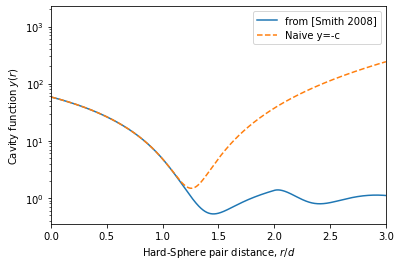

In [10]:
y_from_fortran_program = pd.read_csv('fortran_program/y.csv')
r = y_from_fortran_program['r']
#y = y_from_fortran_program['y']

plt.figure()
plt.plot(r, y_from_fortran_program['y'])

y_equal_c = lambda_1+6*eta*lambda_2*r+0.5*eta*lambda_1*r**3
plt.plot(r, y_equal_c, '--')
plt.yscale('log')
plt.xlim(0, 3)
plt.xlabel('Hard-Sphere pair distance, $r/d$')
plt.ylabel('Cavity function $y(r)$')
plt.legend(['from [Smith 2008]', 'Naive y=-c'])
plt.show()

To get (our own) analytical expression for the cavity function for $d<r<2d$ we use the results presented in [Chang 1993]. Below we consider "the first shell", i.e. the range
$$
d<r<2d
$$
Let
$$
  g(x) = H(x)/x
$$
The expression for H(x) is rather complicated, see below or paper. I compare my implimentation to that of the above mentioned fortran program [Smith 2008] to minimize the chance of typos. Moreover, I make a Taylor-expansion using derivatives at $r=d$ of the PY theory.

In [5]:
# First-shell expresion from [Chang 1994], Eq. 14
from numpy import exp, cos, sin
f = 3 + 3*eta-eta**2
arg = (2*eta**4/f**2+1)**0.5
y_plus = (2*eta*f)**(1/3)*(arg+1)**(1/3)
y_minus = (2*eta*f)**(1/3)*(arg-1)**(1/3)
z_d = y_plus - y_minus
z_s = y_plus + y_minus
A = (-2*eta+z_d)/(1-eta)
B = (-2*eta-0.5*z_d)/(1-eta)
C = 3**(1/2)*z_s/(2*(1-eta))
a_1 = -2*eta*(1-eta-3*eta**2) + (1-3*eta-4*eta**2)*z_d + (1+eta/2)*z_d**2
a_1 = a_1/(3*(2*eta**2+z_d**2)*(1-eta)**2)
a_2 = eta*(2+4*eta-3*eta**2)-(1-3*eta-4*eta**2)*z_d+2*(1+eta/2)*z_d**2
a_2 = a_2/(3*(2*eta**2+z_d**2)*(1-eta)**2)
a_3 = (1-3*eta-4*eta**2)*(4*eta**2+z_d**2)+eta*(2-5*eta**2)*z_d
a_3 = a_3/(3**(1/2)*z_s*(2*eta**2+z_d**2)*(1-eta)**2)
Chang_H1 = (a_1*exp(A*(r-1))+a_2*exp(B*(r-1))*cos(C*(r-1))+a_3*exp(B*(r-1))*sin(C*(r-1)))
Chang_H1 = Chang_H1/r

/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_22871/2643675605.py:19: RuntimeWarning: divide by zero encountered in divide
  Chang_H1 = Chang_H1/r


In [6]:
# Eq. 13 in [Chang 1994] used for a Taylor expression
H1_1 = (1+eta/2)/(1-eta)**2
dH1_1 = (1-5*eta-5*eta**2)/(1-eta)**3
ddH1_1 = -3*eta*(2-4*eta-7*eta**2)/(1-eta)**4
y_Chang_Laplace = (H1_1 + dH1_1*(r-1) + 0.5*ddH1_1*(r-1)**2)/r

/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_22871/2907728481.py:5: RuntimeWarning: divide by zero encountered in divide
  y_Chang_Laplace = (H1_1 + dH1_1*(r-1) + 0.5*ddH1_1*(r-1)**2)/r


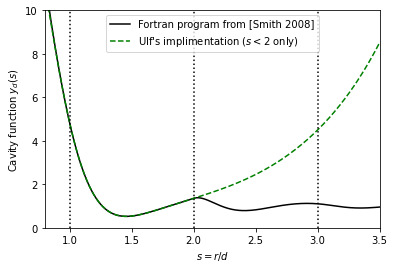

In [13]:
plt.figure()
plt.plot(r, y_from_fortran_program['y'], 'k-')
#y_proxi = lambda_1+6*eta*lambda_2*r+0.5*eta*lambda_1*r**3

#plt.plot(r, y_equal_c, 'b--')
plt.plot(r, Chang_H1, 'g--')
#plt.yscale('log')
#plt.plot(r, y_Chang_Laplace, 'y--')
plt.plot([1, 1], [0, 10], 'k:')
plt.plot([2, 2], [0, 10], 'k:')
plt.plot([3, 3], [0, 10], 'k:')
plt.xlim(0.8, 3.5)
plt.ylim(0, 10)
#plt.ylim(0, 7)
plt.xlabel('$s=r/d$')
plt.ylabel('Cavity function $y_d(s)$')
plt.legend(['Fortran program from [Smith 2008]', "Ulf's implimentation ($s<2$ only)"])
plt.savefig('cavity_function.svg', dpi=600, bbox_inches='tight')
plt.show();

We use the green dashed line in the following.

In [7]:
def get_cavity_function(r, d, eta=0.4908738521234051, verbose=False):
    # Return zeroth and first shell of cavity function
    from numpy import exp, cos, sin
    x = r/d
    
    # Zeroth shell
    lambda_1 = (1+2*eta)**2/(1-eta)**4
    lambda_2 = -(2+eta)**2/(4*(1-eta)**4)
    if verbose:
        print('    Zeroth shell parameters')
        print(f'lambda_1 = {lambda_1:0.4f}')
        print(f'lambda_2 = {lambda_2:0.4f}')    
    x = r/d
    c = (-lambda_1-6*eta*lambda_2*x-0.5*eta*lambda_1*x**3)*np.heaviside(1-x, 0.5)
    y = -c

    # First shell
    f = 3 + 3*eta-eta**2
    arg = (2*eta**4/f**2+1)**0.5
    y_plus = (2*eta*f)**(1/3)*(arg+1)**(1/3)
    y_minus = (2*eta*f)**(1/3)*(arg-1)**(1/3)
    z_d = y_plus - y_minus
    z_s = y_plus + y_minus
    A = (-2*eta+z_d)/(1-eta)
    B = (-2*eta-0.5*z_d)/(1-eta)
    C = 3**(1/2)*z_s/(2*(1-eta))
    a_1 = -2*eta*(1-eta-3*eta**2) + (1-3*eta-4*eta**2)*z_d + (1+eta/2)*z_d**2
    a_1 = a_1/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_2 = eta*(2+4*eta-3*eta**2)-(1-3*eta-4*eta**2)*z_d+2*(1+eta/2)*z_d**2
    a_2 = a_2/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_3 = (1-3*eta-4*eta**2)*(4*eta**2+z_d**2)+eta*(2-5*eta**2)*z_d
    a_3 = a_3/(3**(1/2)*z_s*(2*eta**2+z_d**2)*(1-eta)**2)
    if verbose:
        print('    First shell parameters')
        print(f'A = {A:0.5f}')
        print(f'B = {B:0.5f}')
        print(f'C = {C:0.5f}')
        print(f'a_1 = {a_1:0.5f}')
        print(f'a_2 = {a_2:0.5f}')
        print(f'a_3 = {a_3:0.5f}')
    Chang_H1 = (a_1*exp(A*(x-1))+a_2*exp(B*(x-1))*cos(C*(x-1))+a_3*exp(B*(x-1))*sin(C*(x-1)))
    y += (Chang_H1/x)*(1-np.heaviside(1-x, 0.5))
    return y

# Test implimentation of cavity function
#   by comparing to fortran program by [Smith 2008]
plt.figure()
plt.plot(r, y_from_fortran_program['y'], 'k-', label='from [Smith 2008]')
plt.plot(r, get_cavity_function(r, d, eta, True), 'g--', label="Ulf's implimentation")
plt.xlim(0,2)
plt.ylim(0,20)
plt.xlabel('Pair distance, $r/d$')
plt.ylabel('Cavity function $y(r)$')
plt.legend()
plt.show();

NameError: name 'y_from_fortran_program' is not defined

<Figure size 432x288 with 0 Axes>

    Zeroth shell parameters
lambda_1 = 58.4514
lambda_2 = -23.0856
    First shell parameters
A = 1.58498
B = -3.68494
C = 3.85160
a_1 = 0.56770
a_2 = 4.23705
a_3 = -1.41141


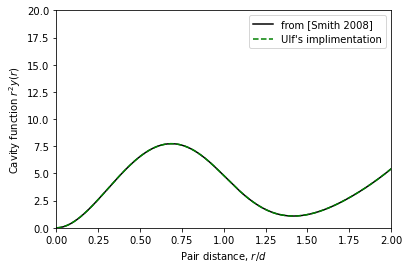

In [15]:
# Test implimentation of cavity function
#   by comparing to fortran program by [Smith 2008]
plt.figure()
plt.plot(r, r*r*y_from_fortran_program['y'], 'k-', label='from [Smith 2008]')
plt.plot(r, r*r*get_cavity_function(r, 1.0, eta, True), 'g--', label="Ulf's implimentation")
plt.xlim(0,2)
plt.ylim(0,20)
plt.xlabel('Pair distance, $r/d$')
plt.ylabel('Cavity function $r^2y(r)$')
plt.legend()
plt.show();

# The AWC integral
Let 
\begin{equation}
	e(r)=\exp(-v(r)/T)
\end{equation}
The effective hard-sphere diameter suggested by [Weeks 1971] is given by
\begin{equation}
	\int_0^\infty y_d(r)\Delta e(r)r^2dr = 0
\end{equation}
where $\Delta e(r)=e(r)-e_d(r)$ is the blip-function, and $y_d(r)$ is the radial cavity function of hard-spheres. For the hard-sphere system, $y_d(r)=g_d(r)$ for $r\geq d$ and $y_d(r)=-c(r)$ for $r>d$. Here, $g(r)$ is the radial distribution function, and $c(r)$ is the direct correlation function defined by the Ornstein-Zernike equation. This was what we evalated above at the coexistence density.

First we discuss the blip-function:

Temperature 2.0
Hard-Sphere diameter 0.98068484


/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_22871/2460695851.py:7: RuntimeWarning: divide by zero encountered in divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


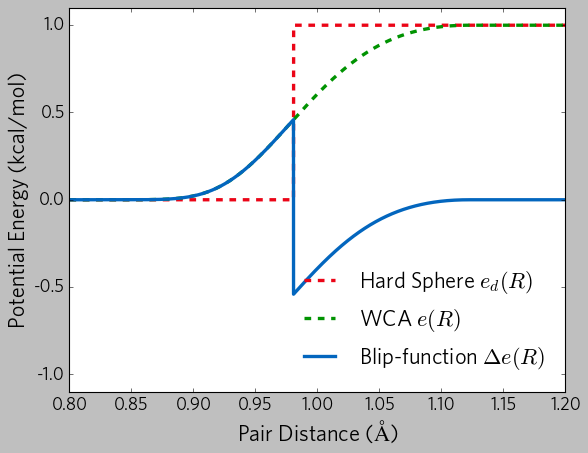

In [10]:
r = np.linspace(0.7, 1.4, 2**14)
T = 2.0
print('Temperature', T)
beta = 1/T
d = 0.98068484#0.88*2**(1/6)
print('Hard-Sphere diameter', d)
v_d = 1/np.heaviside(r-d, 0.5)-1
e_d = np.exp(-beta*v_d)
v_0 = (4*r**-12-4*r**-6+1)*(r<2**(1/6))
e_0 = np.exp(-beta*v_0)
plt.style.use('classic')
plt.figure(figsize=(8, 6))
plt.rcParams.update({
    #'font.family': 'DejaVu Sans',   # Default font
    'font.family': 'Whitney Book', # Actual font used in the paper (needs to install font first)
    'axes.unicode_minus': False
})
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.plot(r, e_d, linestyle='--', color='#eb0517', linewidth=3)  # Red color
plt.plot(r, e_0, linestyle='--', color='#009301', linewidth=3)  # Green color
Delta_e = e_0-e_d
plt.plot(r, Delta_e, linestyle='-', color='#0366be', linewidth=3)  # Blue color

#plt.plot([2**(1/6), 2**(1/6)], [-1.1, 1.1], 'k:')
plt.xlabel(r'Pair Distance ($\mathrm{\AA}$)',fontsize=20)
plt.ylabel(r'Potential Energy (kcal/mol)',fontsize=20)
#plt.legend(['$e_d(r)$ with  $d=$' + f'{d:0.3f}', 
#            r'$e(r)=\exp(-v(r)/kT)$ with $T=$' + f'{T:0.2f}', 
#           r'Blip-function: $\Delta e(r)=e(r)-e_d(r)$'], frameon=False, loc='lower right', fontsize=16)
plt.legend(['Hard Sphere $e_d(R)$', 
            r'WCA $e(R)$', 
           r'Blip-function $\Delta e(R)$'], frameon=False, loc='lower right', fontsize=20)

plt.ylim(-1.1, 1.1)
plt.xlim(0.8, 1.2)
plt.savefig('blip_function.pdf', dpi=600, bbox_inches='tight')
plt.savefig('blip_function.png', dpi=600, bbox_inches='tight')

plt.show();

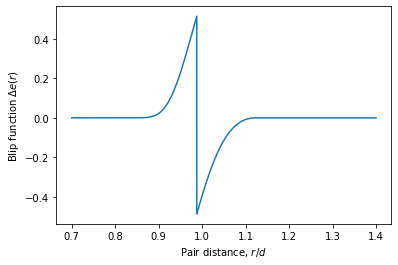

In [7]:
Delta_e = e_0-e_d

plt.figure()
plt.plot(r, Delta_e)
plt.xlabel('Pair distance, $r/d$')
plt.ylabel('Blip function $\Delta e(r)$')
plt.show();

AWC integral:  -0.01445011642745242


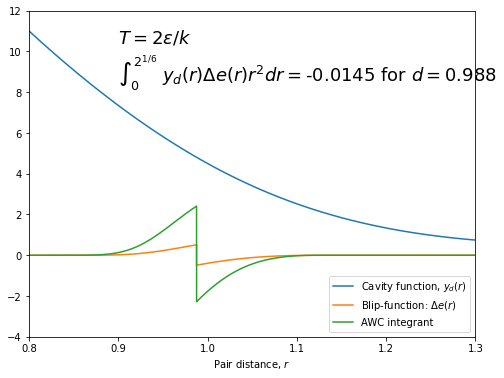

In [8]:
y = get_cavity_function(r, d)
integrant = y*Delta_e*r*r
AWC_integral = np.trapz(r, integrant)
print('AWC integral: ', AWC_integral)

plt.figure(figsize=(8, 6))
s = r'$T=2\varepsilon/k$' + f'\n'
s = s + '$\int_0^{2^{1/6}} \  y_d(r)\Delta e(r)r^2dr=$' + f'{AWC_integral:0.3}'  + ' for $d=$' + f'{d:0.3}'
plt.text(0.9, 8.5, s, fontsize=18)
plt.plot(r, y)
plt.plot(r, Delta_e)
plt.plot(r, integrant)
plt.legend([r'Cavity function, $y_d(r)$', r'Blip-function: $\Delta e(r)$', 'AWC integrant'], loc='lower right')
plt.xlabel('Pair distance, $r$')
plt.xlim(0.8, 1.3)
plt.ylim(-4, 12)
plt.savefig('awc_integral.svg', dpi=600, bbox_inches='tight')
plt.show()



/tmp/ipykernel_28396/1967589357.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


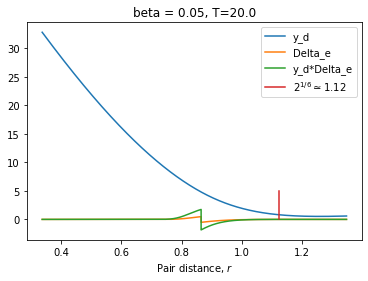

-0.01059251915668678

In [19]:
def awc_integral(f_d=0.88, beta=1/0.02, verbose=False):
    x = np.linspace(0.3, 1.2, 2**18)
    r = x*2**(1/6)
    d = f_d*2**(1/6)
    rho_HS = 0.9375/d**3  # Coexistence density from litterature
    eta = np.pi*rho_HS*d**3/6
    y_d = get_cavity_function(r, d, eta)
    
    v_d = 1/np.heaviside(r-d, 0.5)-1
    e_d = np.exp(-beta*v_d)
    v_0 = (4*r**-12-4*r**-6 + 1)*np.heaviside(2**(1/6)-r, 0.5)
    e_0 = np.exp(-beta*v_0)
    Delta_e = e_0-e_d
    if verbose:
        plt.figure()
        plt.title(f'beta = {beta}, T={1/beta}')
        plt.plot(r, y_d)        
        plt.plot(r, Delta_e)
        plt.plot(r, y_d*Delta_e*r*r)
        plt.plot([2**(1/6), 2**(1/6)], [0, 5])
        plt.xlabel('Pair distance, $r$')
        plt.legend(['y_d', 'Delta_e', 'y_d*Delta_e', r'$2^{1/6}\simeq1.12$'])
        plt.show()
    return np.trapz(y_d*Delta_e*r*r, r)

awc_integral(0.77, 0.05, verbose=True)

/tmp/ipykernel_28396/1967589357.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


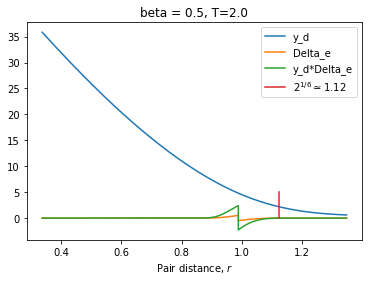

0.01454281088102536

In [20]:
awc_integral(0.88, 0.5, verbose=True)

/tmp/ipykernel_28396/1967589357.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


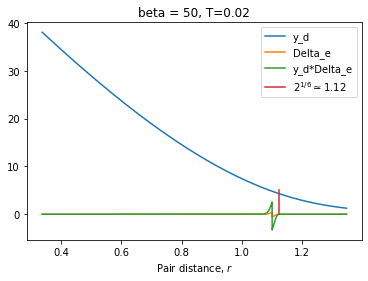

-0.0044751680289295825

In [21]:
awc_integral(0.98, 50, verbose=True)

We need to find the value of $d$ where the AWC integral vanish. We use the SciPy for this:

/tmp/ipykernel_28396/1967589357.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


d where integral vanish: [0.98068484]


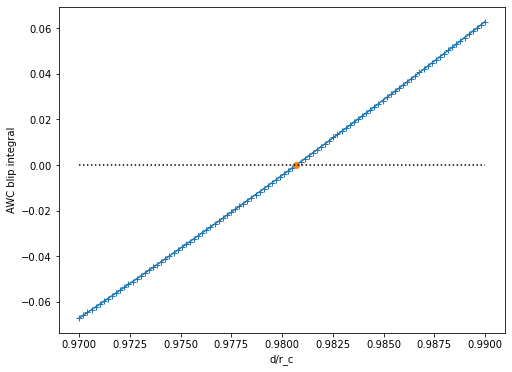

In [22]:
beta=1/0.02
fs = np.linspace(0.97, 0.99, 100)
awc = [awc_integral(f, beta) for f in fs]

from scipy import optimize
sol = optimize.root(awc_integral, 0.98, args=(beta))
print('d where integral vanish:', sol.x)

plt.figure(figsize=(8, 6))
plt.plot(fs, awc, '-+')
plt.plot(sol.x, 0, 'o')
plt.plot([min(fs), max(fs)], [0, 0],'k:')
plt.xlabel('d/r_c')
plt.ylabel('AWC blip integral')
plt.savefig('awc_integral_02.svg', dpi=600, bbox_inches='tight')
plt.show()

In [23]:
df_cc = pd.read_csv('../clausius_clapeyron_pc.csv')
#df_cc = pd.read_csv('../clausius_clapeyron.csv')  # RK4 integration

df_cc = df_cc.sort_values(by='T')
df_cc

,T,p,v_fcc,v_liquid,u_fcc,u_liquid,slope0,slope1
31,0.001022,0.008471,1.344674,1.485143,0.000071,0.000080,8.352112,8.343373
30,0.001125,0.009331,1.343844,1.484308,0.000082,0.000092,8.361522,8.352270
29,0.001238,0.010278,1.342863,1.483125,0.000095,0.000106,8.371401,8.361599
28,0.001363,0.011322,1.341938,1.482135,0.000109,0.000123,8.381664,8.371421
27,0.001500,0.012473,1.340823,1.480706,0.000125,0.000141,8.392328,8.381389
...,...,...,...,...,...,...,...,...
99,13.625840,384.288100,0.587939,0.613666,40.318910,43.327680,36.819490,37.858800
100,14.997880,435.519000,0.575172,0.600038,45.274950,48.563760,37.862580,38.917390
101,16.508080,493.495500,0.562600,0.586685,50.792230,54.396050,38.936840,40.003810
102,18.170350,559.105800,0.550200,0.573623,56.944450,60.862380,40.011620,41.100360


Below we compute the $d$'s for all the temperatures evaluated for the WCA-coexistence line:

In [24]:
T = df_cc['T']
beta_list = 1/T
fs_awc = []
for beta in beta_list:
    sol = optimize.root(awc_integral, 0.98, args=(beta))
    fs_awc.append(sol.x[0])

/tmp/ipykernel_28396/1967589357.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


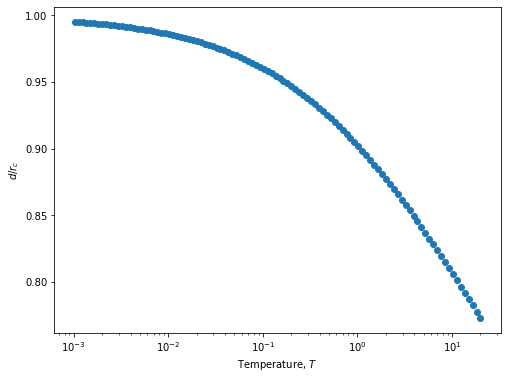

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(T, fs_awc, 'o')
plt.xscale('log')
plt.xlabel(r'Temperature, $T$')
plt.ylabel('$d/r_c$')
plt.savefig('awc_hs_diameters.svg', dpi=600, bbox_inches='tight')
plt.show()

# Comparing predictions of shape of coexistence line

We can now evaluate the AWC coexistence pressure and compare it to numerical calculations
$$
  p = 11.5712(10)k_BT/d^3
$$

Below we the true WCA coexistence line to 
* Zero-temperature limit
$$
    d = r_c = 2^{1/6} \simeq 1.12
$$
* Andersen-Weeks-Chandler (AWC)
$$
	\int_0^\infty y_d(r)\Delta e(r)r^2dr = 0
$$
* Barker-Henderson (BH) criteroin
$$
	d = \int_0^\infty[1-e(r)]dr
$$
* Stillinger criterion
$$
  e(d) = \frac{1}{2}
$$
* Boltzmann criterion
$$
    v(d) = kT
$$

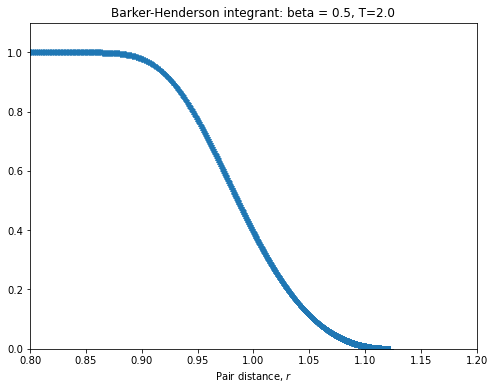

d =  0.9883272226385659


0.9883272226385659

In [26]:
# Evaluate the Barker-Henderson expression
def sigma_BH(beta, verbose=False):
    from scipy.integrate import trapz
    from numpy import logspace
    from math import exp
    rc=2**(1/6)
    a, b = rc, 1e-8
    r = (b-a)*logspace(-8, 0, 10000)+a
    f = [1-exp(-beta*(4*r**-12-4*r**-6+1)) for r in r]
    d = -trapz(f, r)
    if verbose:
        plt.figure(figsize=(8, 6));
        plt.title(f'Barker-Henderson integrant: beta = {beta}, T={1/beta}')
        plt.plot(r, f, '+')
        plt.xlabel('Pair distance, $r$')
        plt.xlim(0.8, 1.2)
        plt.ylim(0, 1.1)
        plt.savefig('bh_integral.svg', dpi=600, bbox_inches='tight')
        
        plt.show()
        print('d = ', d)
    return d
sigma_BH(0.5, True)

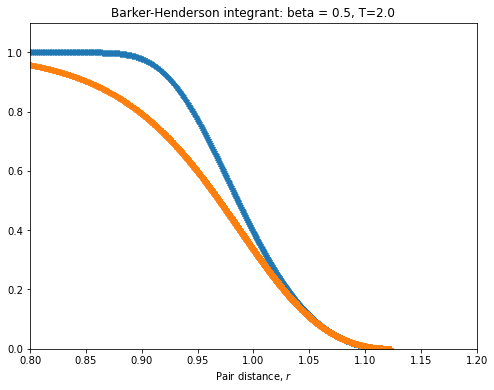

d =  0.9583490106079229


0.9583490106079229

In [27]:
# Evaluate the Barker-Henderson expression
def sigma_BH_low_T(beta, verbose=False):
    from scipy.integrate import trapz
    from numpy import logspace
    from math import exp
    rc=2**(1/6)
    a, b = rc, 1e-8
    r = (b-a)*logspace(-8, 0, 10000)+a
    f_true = [1-exp(-beta*(4*r**-12-4*r**-6+1)) for r in r]
    f = [1-1/(1+beta*(4*r**-12-4*r**-6+1)) for r in r]
    d = -trapz(f, r)
    if verbose:
        plt.figure(figsize=(8, 6));
        plt.title(f'Barker-Henderson integrant: beta = {beta}, T={1/beta}')
        plt.plot(r, f_true, '+')
        plt.plot(r, f, '*')
        plt.xlabel('Pair distance, $r$')
        plt.xlim(0.8, 1.2)
        plt.ylim(0, 1.1)
        
        plt.show()
        print('d = ', d)
    return d
sigma_BH_low_T(0.5, True)

In [28]:
plt.style.use('classic')

In [29]:
p_d = 11.5712
p_bullet = p_d*df_cc['T']/2**0.5

In [30]:
df_ip = pd.read_csv('../coexistence_line_ip.csv')
df_ip['p_bullet'] = p_d*df_ip['T']/2**0.5
df_ip

,T,p,rho_l,rho_s,p_error,rho_l_error,rho_s_error,p_bullet
0,0.002,0.016687,0.677174,0.747911,0.000003,0.000025,0.000033,0.016364
1,0.020,0.174944,0.706377,0.778886,0.000047,0.000048,0.000056,0.163641
2,0.200,2.051686,0.800040,0.873563,0.000329,0.000033,0.000036,1.636415
3,2.000,31.808648,1.084410,1.151919,0.006594,0.000051,0.000059,16.364148
4,20.000,634.245413,1.784033,1.859271,0.208595,0.000177,0.000169,163.641480


0.75


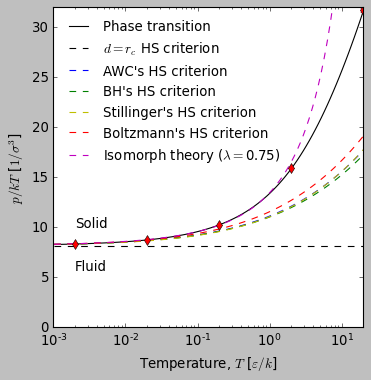

In [31]:
plt.figure(figsize=(5, 5))

# Coexistence line
plt.plot(T, df_cc['p']/T, 'k-', label=r'Phase transition')
#plt.plot(df_ip['T'], df_ip['p']/df_ip['T'], 'rd')
plt.errorbar(df_ip['T'], df_ip['p']/df_ip['T'], df_ip['p_error'], fmt='rd', linestyle=None)

# Zero-temperature limit
rc = 2**(1/6)
p_0 = p_d*T/rc**3
plt.plot(T, p_0/T, 'k--', label='$d=r_c$ HS criterion')

# AWC prediction
d_awc = np.array(fs_awc)*2**(1/6)
p_awc = p_d*T/d_awc**3
plt.plot(T, p_awc/T, 'b--', label="AWC's HS criterion")

# BH prediction
d_bh = np.array([sigma_BH(beta) for beta in 1/T])
p_bh = p_d*T/d_bh**3
plt.plot(T, p_bh/T, 'g--', label="BH's HS criterion")

# Stillinger prediction
d_stillinger = 2**(1/6)/np.power(1+np.sqrt(T*np.log(2)), 1/6) 
p_stillinger = p_d*T/d_stillinger**3
plt.plot(T, p_stillinger/T, 'y--', label=r"Stillinger's HS criterion")

# Boltzmann prediction, v(d) = kT
d_boltzmann = 2**(1/6)/np.power(1+np.sqrt(T), 1/6)
p_boltzmann = p_d*T/d_boltzmann**3
plt.plot(T, p_boltzmann/T, 'r--', label=r"Boltzmann's HS criterion")

# Ben-Amotz and Herschbac
#T_bah = 1.4
#d_bah = 2**(1/6)/np.power(1+np.sqrt(T/T_bah), 1/6)
#p_bah = 11.5727*T/d_bah**3
#plt.plot(T, p_bah/T, 'k--', label=r"Ben-Amotz Herschbach HS criterion")

# Isomorph theory
k_2 = 36*4**(1/3)
r_c = 2**(1/6)
lam = 3/4
print(lam)
p_isom = p_bullet*np.exp(lam*9*(np.pi*T)**0.5/2/r_c/(2*k_2)**0.5)
plt.plot(T, p_isom/T, 'm--', label=r"Isomorph theory ($\lambda =$" + f"{lam:.2})")

plt.xscale('log')
plt.xlabel(r'Temperature, $T$ [$\varepsilon/k$]')
plt.ylabel(r'$p/kT$ [$1/\sigma^3$]')
plt.ylim(0, 32)
plt.xlim(1e-3,20)
plt.legend(loc='upper left', fontsize='medium', frameon=False)

plt.text(2e-3, 10, 'Solid')
plt.text(2e-3, 5.7, 'Fluid')

#plt.savefig('HS_theory.pdf', dpi=600)
#plt.savefig('HS_theory.svg', dpi=600, bbox_inches='tight')

plt.show()

In [32]:
# Lav csv fil
df=pd.DataFrame({'T': T,
                 'd_awc': d_awc, 
                 'd_bh': d_bh,
                 'd_boltzmann': d_boltzmann,
                 'd_stillinger': d_stillinger,
                 'p_awc': p_awc, 
                 'p_bh': p_bh,
                 'p_boltzmann': p_boltzmann,
                 'p_stillinger': p_stillinger
                }).set_index('T')

df.to_csv('HS_theory.csv')

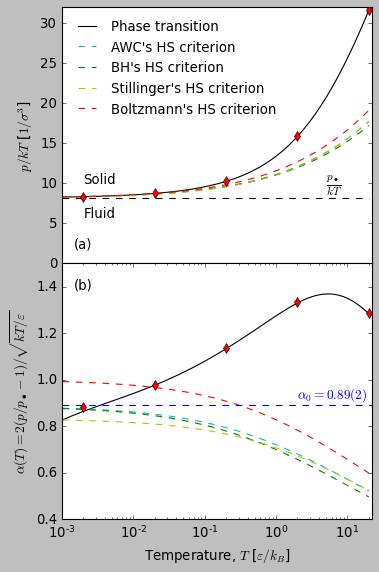

In [42]:
plt.figure(figsize=(5, 8))

plt.subplot(2,1,1)
plt.plot(T, df_cc['p']/T, 'k-', label=r'Phase transition')
plt.errorbar(df_ip['T'], df_ip['p']/df_ip['T'], [df_ip['p_error'], df_ip['p_error']], fmt='rd', linestyle=None)

#plt.plot(T, p_0/T, 'k--', label='$d=r_c$ HS criterion')
plt.plot(T, p_0/T, 'k--')
plt.plot(T, p_awc/T, 'c--', label="AWC's HS criterion")
plt.plot(T, p_bh/T, 'g--', label="BH's HS criterion")
plt.plot(T, p_stillinger/T, 'y--', label=r"Stillinger's HS criterion")
plt.plot(T, p_boltzmann/T, 'r--', label=r"Boltzmann's HS criterion")
#plt.plot(T, p_isom/T, 'm--', label=r"Isomorph theory ($\lambda =$" + f"{lam:.2})")
plt.xscale('log')
#plt.xlabel(r'Temperature, $T$ [$\varepsilon/k$]')
plt.gca().axes.get_xaxis().set_visible(False)
plt.ylabel(r'$p/kT$ [$1/\sigma^3$]')
plt.ylim(0, 32)
plt.xlim(1e-3,22)
plt.legend(loc='upper left', fontsize='medium', frameon=False)
plt.text(0.04, 0.06, '(a)', transform=plt.gca().transAxes)
plt.text(5, 9.4, r'$\frac{p_\bullet}{kT}$', fontsize='large')
plt.text(2e-3, 10, 'Solid')
plt.text(2e-3, 5.7, 'Fluid')

plt.subplot(2,1,2)
plt.plot(T, 2*(df_cc['p']/p_bullet-1)/T**0.5, 'k-', label=r'Phase transition')
alpha_mid = 2*(df_ip['p']/df_ip['p_bullet']-1)/df_ip['T']**0.5
alpha_up = 2*((df_ip['p']+df_ip['p_error'])/df_ip['p_bullet']-1)/df_ip['T']**0.5
alpha_low = 2*((df_ip['p']-df_ip['p_error'])/df_ip['p_bullet']-1)/df_ip['T']**0.5
alpha_err_up = ((alpha_up-alpha_mid)**2)**0.5
alpha_err_low = ((alpha_low-alpha_mid)**2)**0.5
plt.errorbar(df_ip['T'], 2*(df_ip['p']/df_ip['p_bullet'] -1)/df_ip['T']**0.5, [alpha_err_low, alpha_err_up], fmt='rd', linestyle=None)
plt.plot(T, 2*(p_awc/p_bullet-1)/T**0.5, 'c--', label="AWC's HS criterion")
plt.plot(T, 2*(p_bh/p_bullet-1)/T**0.5, 'g--', label="BH's HS criterion")
plt.plot(T, 2*(p_stillinger/p_bullet-1)/T**0.5, 'y--', label=r"Stillinger's HS criterion")
plt.plot(T, 2*(p_boltzmann/p_bullet-1)/T**0.5, 'r--', label=r"Boltzmann's HS criterion")
TT = np.array([1e-3, 22])
plt.plot(TT, 0.89*TT/TT, 'b--')
plt.text(2, 0.92, r'$\alpha_0=0.89(2)$', color='blue')
#x = df_cc[df_cc['T']==0.002]  
#plt.errorbar(df_cc[df_cc['T']==0.002]

#plt.plot(T, 2*(p_isom/p_bullet-1)/T**0.5, 'm--',label=r"Isomorph theory ($\lambda =$" + f"{lam:.2})")
plt.xlabel(r'Temperature, $T$ [$\varepsilon/k_B$]')
plt.ylabel(r'$\alpha(T)=2(p/p_\bullet-1)/\sqrt{kT/\varepsilon}$')
plt.xscale('log')
plt.text(0.04, 0.9, '(b)', transform=plt.gca().transAxes)
plt.xlim(1e-3, 22)
plt.ylim(0.4, 1.5)

#plt.legend(loc='lower right', fontsize='medium', frameon=False)

plt.subplots_adjust(hspace=0)

plt.savefig('HS_theory.pdf', dpi=600)
plt.savefig('HS_theory.svg', dpi=600, bbox_inches='tight')

plt.show()

In [34]:
df_cc[df_cc['T']==0.002]

,T,p,v_fcc,v_liquid,u_fcc,u_liquid,slope0,slope1
24,0.002,0.01668,1.337046,1.476995,0.000192,0.000216,8.428581,8.415753


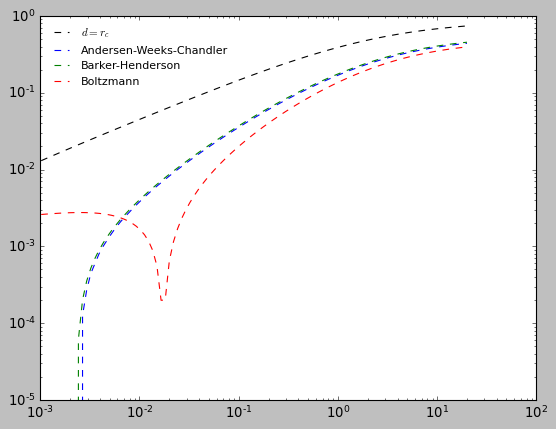

In [35]:
#plt.figure(figsize=(4,3))
plt.plot(T, 1-p_0/df_cc['p'], 'k--', label='$d=r_c$')
plt.plot(T, 1-p_awc/df_cc['p'], 'b--', label='Andersen-Weeks-Chandler')
plt.plot(T, 1-p_bh/df_cc['p'], 'g--', label='Barker-Henderson')
plt.plot(T, np.abs(1-p_boltzmann/df_cc['p']), 'r--', label=r'Boltzmann')
# plt.plot(T, np.abs(1-p_bah/df_cc['p']), 'y--', label='Ben-Amotz Herschbach HS criterion')

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper left', fontsize='small', frameon=False)

plt.show()

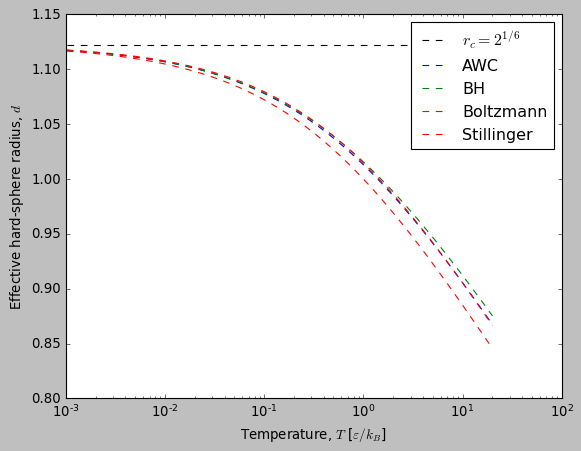

In [36]:
plt.plot()
plt.plot(T, T*rc/T, 'k--', label='$r_c=2^{1/6}$')
plt.plot(T, d_awc, 'b--', label='AWC')
plt.plot(T, d_bh, 'g--', label='BH')
plt.plot(T, d_boltzmann, 'r--', label='Boltzmann')
plt.plot(T, d_stillinger, 'r--', label='Stillinger')

#plt.plot(T, d_bah, 'y--', label='Ben-Amotz Herschbach HS criterion')

plt.xlabel(r'Temperature, $T$ [$\varepsilon/k_B$]')
plt.ylabel(r'Effective hard-sphere radius, $d$')
plt.xscale('log')
plt.legend()
plt.show()

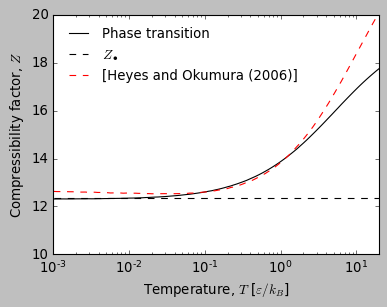

In [37]:
plt.figure(figsize=(5, 4))
Z = df_cc['p']*df_cc['v_liquid']/df_cc['T']
plt.plot(df_cc['T'], Z, 'k-', label='Phase transition')


rho = 0.9375  # Coexistence density from litterature
eta = np.pi*rho*d**3/6
Z_HS = p_0/T/rho*2**0.5
plt.plot(df_cc['T'], Z_HS, 'k--', label=r'$Z_\bullet$')

# carnahan starling / Heyes-Okumura
a_cs=3.597 # 1 # 17.22
b_cs=5.836 # 1 # 31.1
eta_cs = np.pi*d_boltzmann**3/df_cc['v_liquid']/6
Z_cs = (1+eta_cs+a_cs*eta_cs**2-b_cs*eta_cs**3)/(1-eta_cs)**3
plt.plot(df_cc['T'], Z_cs, 'r--', label=r'[Heyes and Okumura (2006)]')

plt.ylabel(r'Compressibility factor, $Z$')
plt.ylim(10, 20)
plt.xlabel(r'Temperature, $T$ [$\varepsilon/k_B$]')
plt.xscale('log')
plt.xlim(1e-3, 20)

plt.legend(loc='upper left', fontsize='medium', frameon=False)
plt.tight_layout()

plt.savefig('compressibility_factor.pdf', dpi=600)

plt.show()

In [38]:
alpha_awc = (1-d_awc/2**(1/6))/T**0.5*6
alpha_awc

31     0.869423
30     0.869101
29     0.867952
28     0.867688
27     0.866220
         ...   
99     0.338558
100    0.329993
101    0.321521
102    0.313157
103    0.304901
Name: T, Length: 104, dtype: float64

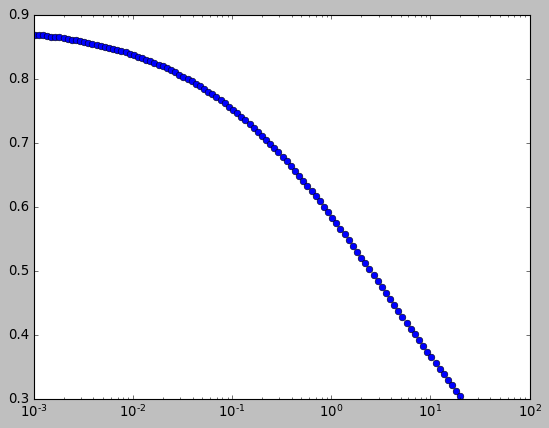

In [39]:

plt.plot(T,alpha_awc, 'o')
plt.xscale('log')

/tmp/ipykernel_28396/3190096956.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


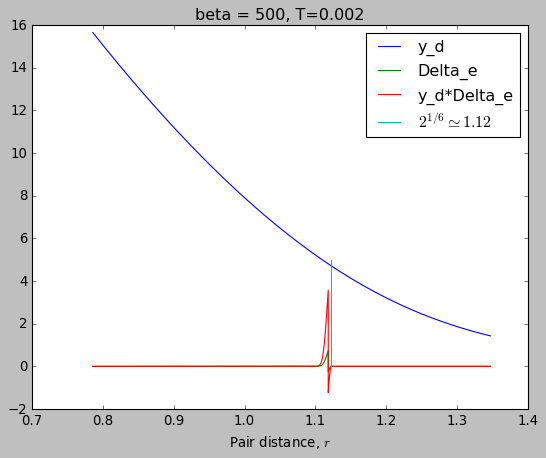

0.013279289323852153

In [40]:
def awc_integral_low(f_d=0.88, beta=1/0.02, verbose=False):
    x = np.linspace(0.7, 1.2, 2**19)
    r = x*2**(1/6)
    d = f_d*2**(1/6)
    rho_HS = 0.9375/d**3  # Coexistence density from litterature
    eta = np.pi*rho_HS*d**3/6
    y_d = get_cavity_function(r, d, eta)
    
    v_d = 1/np.heaviside(r-d, 0.5)-1
    e_d = np.exp(-beta*v_d)
    v_0 = (4*r**-12-4*r**-6 + 1)*np.heaviside(2**(1/6)-r, 0.5)
    e_0 = np.exp(-beta*v_0)
    Delta_e = e_0-e_d
    if verbose:
        plt.figure()
        plt.title(f'beta = {beta}, T={1/beta}')
        plt.plot(r, y_d)        
        plt.plot(r, Delta_e)
        plt.plot(r, y_d*Delta_e)
        plt.plot([2**(1/6), 2**(1/6)], [0, 5])
        plt.xlabel('Pair distance, $r$')
        plt.legend(['y_d', 'Delta_e', 'y_d*Delta_e', r'$2^{1/6}\simeq1.12$'])
        plt.show()
    return np.trapz(y_d*Delta_e, r)

awc_integral_low(0.996, 500, verbose=True)

/tmp/ipykernel_28396/3190096956.py:9: RuntimeWarning: divide by zero encountered in true_divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


1000000.0 [0.99985216]
837677.6400682924 [0.99983874]
701703.8286703823 [0.99982342]
587801.6072274912 [0.99980764]
492388.26317067415 [0.99978908]
412462.6382901348 [0.99977003]
345510.7294592218 [0.99974884]
289426.6124716752 [0.99972547]
242446.2017082331 [0.99970056]
203091.76209047346 [0.99967193]
170125.4279852589 [0.99964222]
142510.2670302996 [0.99960927]
119377.66417144358 [0.99957298]
99999.99999999999 [0.99953368]
83767.76400682924 [0.99949075]
70170.38286703822 [0.99944378]
58780.16072274912 [0.99939169]
49238.82631706742 [0.99933537]
41246.26382901348 [0.99927463]
34551.072945922184 [0.99920823]
28942.66124716752 [0.99913408]
24244.62017082331 [0.99905486]
20309.17620904735 [0.998967]
17012.54279852589 [0.99887192]
14251.026703029964 [0.99876779]
11937.766417144358 [0.99865465]
10000.0 [0.99853028]
8376.776400682917 [0.99839636]
7017.0382867038215 [0.99824864]
5878.016072274912 [0.99808695]
4923.882631706737 [0.99791196]
4124.626382901352 [0.9977201]
3455.1072945922183 [0.

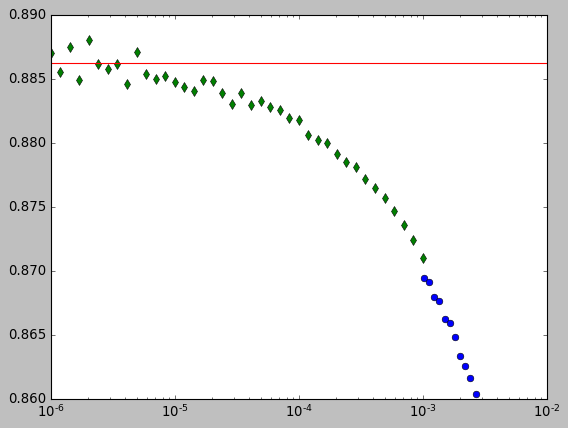

In [41]:
options = dict()

T_low = np.logspace(-6, -3, 40)
betas_low = 1/T_low
fs_awc_low = []
for beta in betas_low:
    sol = optimize.root(awc_integral_low, 0.89, args=(beta))
    fs_awc_low.append(sol.x[0])
    print(beta, sol.x)

alpha_awc_low = (1-np.array(fs_awc_low))/T_low**0.5*6

plt.plot(T,alpha_awc, 'o')
plt.plot(T_low,alpha_awc_low, 'd')
plt.plot([1e-6, 1], [0.5*np.pi**0.5, 0.5*np.pi**0.5])
plt.ylim(0.86, 0.89)
plt.xlim(1e-6, 1e-2)
plt.xscale('log')